# Part 5: Results and Discussion

This final stage collects the saved results from Parts 1–4. It does not fit another
model or change any earlier calculation. Volatility forecast accuracy and VaR coverage
are reported separately because they answer different risk questions.

In [1]:
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'scripts').is_dir() and (path / 'data').is_dir()
)
TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

returns = pd.read_csv(
    PROJECT_ROOT / 'data/processed/daily_returns.csv',
    index_col='Date',
    parse_dates=True,
)
validation = pd.read_csv(TABLE_DIR / 'validation_metrics.csv')
test = pd.read_csv(TABLE_DIR / 'test_metrics.csv')
splits = pd.read_csv(TABLE_DIR / 'time_splits.csv')
backtests = pd.read_csv(TABLE_DIR / 'kupiec_backtests.csv')
selection = json.loads((TABLE_DIR / 'model_selection.json').read_text(encoding='utf-8'))
part1_report = json.loads((TABLE_DIR / 'part1_quality_report.json').read_text(encoding='utf-8'))
part2_report = json.loads((TABLE_DIR / 'part2_quality_report.json').read_text(encoding='utf-8'))
part3_report = json.loads((TABLE_DIR / 'part3_quality_report.json').read_text(encoding='utf-8'))
part4_report = json.loads((TABLE_DIR / 'part4_quality_report.json').read_text(encoding='utf-8'))

expected_assets = ['SPY', 'QQQ', 'IWM', 'TLT', 'HYG', 'GLD', 'DBC']
expected_test_models = ['Historical Volatility', 'EWMA', 'Linear Regression']
assert list(returns.columns) == expected_assets
assert not returns.isna().any().any()
assert selection['selected_ml_model'] == 'Linear Regression'
assert list(test['model']) == expected_test_models
assert part1_report['calendar_audit']['missing_sessions'] == 0
assert all(report['status'] == 'PASS' for report in [part2_report, part3_report, part4_report])
print('Loaded the frozen, validated outputs from Parts 1–4.')

Loaded the frozen, validated outputs from Parts 1–4.


## Data and portfolio overview

SPY, QQQ and IWM cover three US equity segments. TLT represents long-duration US
Treasuries, HYG high-yield corporate bonds, GLD gold and DBC broad commodities.
The portfolio return is the daily mean of the seven ETF returns, equivalent to constant
1/7 weights. Full-sample statistics below are descriptive and were not used for fitting.

,observations,mean_daily_return,annualized_volatility,zero_returns,negative_returns,start_date,end_date
SPY,4200,0.000579,0.170608,12,1868,2010-01-05,2026-09-16
QQQ,4200,0.000767,0.206462,16,1841,2010-01-05,2026-09-16
IWM,4200,0.000506,0.221529,6,1947,2010-01-05,2026-09-16
TLT,4200,0.000136,0.149031,15,2003,2010-01-05,2026-09-16
HYG,4200,0.000213,0.081903,64,1902,2010-01-05,2026-09-16
GLD,4200,0.000359,0.167652,13,1965,2010-01-05,2026-09-16
DBC,4200,0.000165,0.174106,80,1949,2010-01-05,2026-09-16
Equal-weight portfolio,4200,0.000389,0.106174,0,1875,2010-01-05,2026-09-16


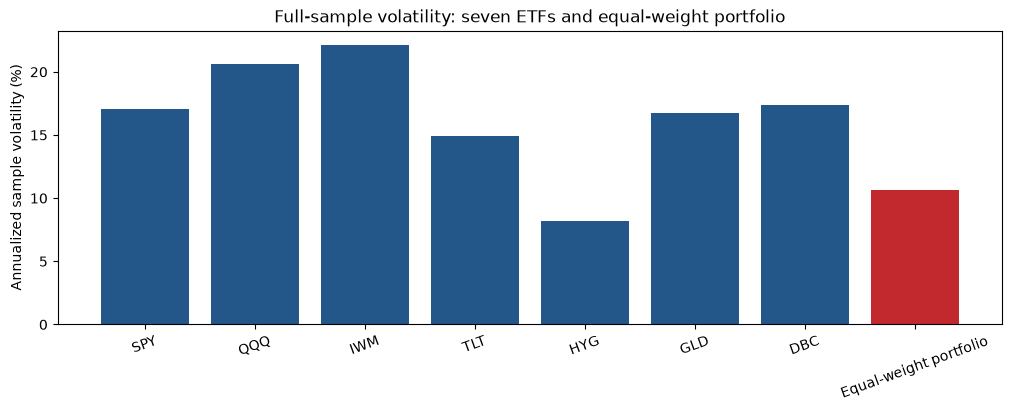

In [2]:
returns['Equal-weight portfolio'] = returns.mean(axis=1)
overview = pd.DataFrame({
    'observations': returns.count(),
    'mean_daily_return': returns.mean(),
    'annualized_volatility': returns.std(ddof=1) * np.sqrt(252),
    'zero_returns': returns.eq(0).sum(),
    'negative_returns': returns.lt(0).sum(),
})
overview['start_date'] = str(returns.index.min().date())
overview['end_date'] = str(returns.index.max().date())
overview.to_csv(TABLE_DIR / 'asset_portfolio_overview.csv', index_label='asset')
display(overview)

figure, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
colors = ['#235789'] * 7 + ['#c1292e']
axis.bar(overview.index, overview['annualized_volatility'] * 100, color=colors)
axis.set_ylabel('Annualized sample volatility (%)')
axis.set_title('Full-sample volatility: seven ETFs and equal-weight portfolio')
axis.tick_params(axis='x', rotation=20)
figure.savefig(FIGURE_DIR / 'asset_portfolio_volatility.png', dpi=160)
if plt.get_backend().lower() != 'agg':
    plt.show()
plt.close(figure)

## Volatility forecast results

Validation MAE was the model-selection metric. Random Forest and XGBoost appear only in
validation because the test set was reserved for the chosen ML model and the two baselines.
MAE and RMSE are annualized volatility decimals; 0.01 is one volatility percentage point.

,model,MAE_validation,RMSE_validation,MAE_test,RMSE_test,test_status
0,Linear Regression,0.035246,0.056723,0.035502,0.052967,evaluated
1,XGBoost,0.035950,0.061745,NaN,NaN,not evaluated: not selected on validation
2,Random Forest,0.037528,0.064782,NaN,NaN,not evaluated: not selected on validation
3,Historical Volatility,0.041307,0.063688,0.040831,0.060382,evaluated
4,EWMA,0.041399,0.061941,0.039416,0.057162,evaluated


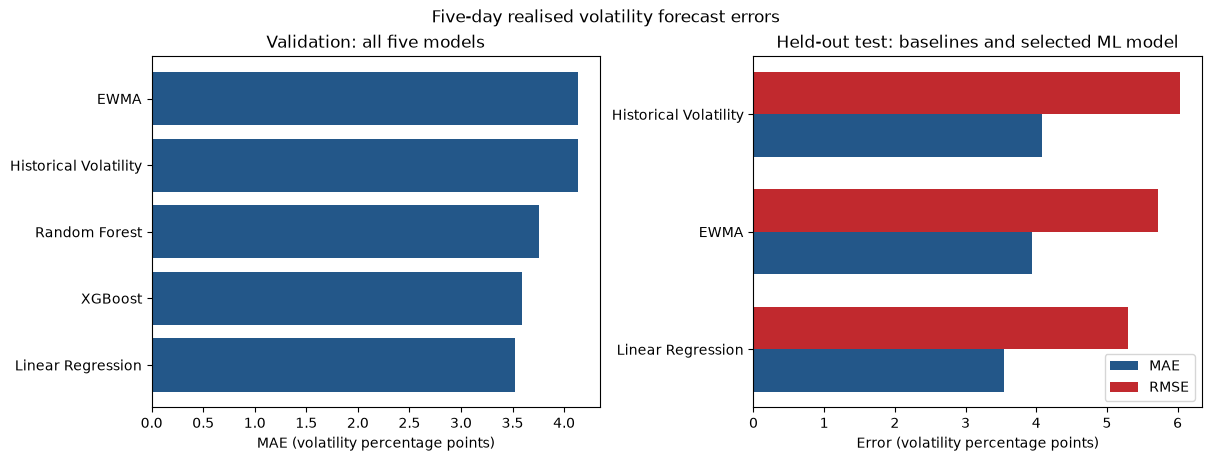

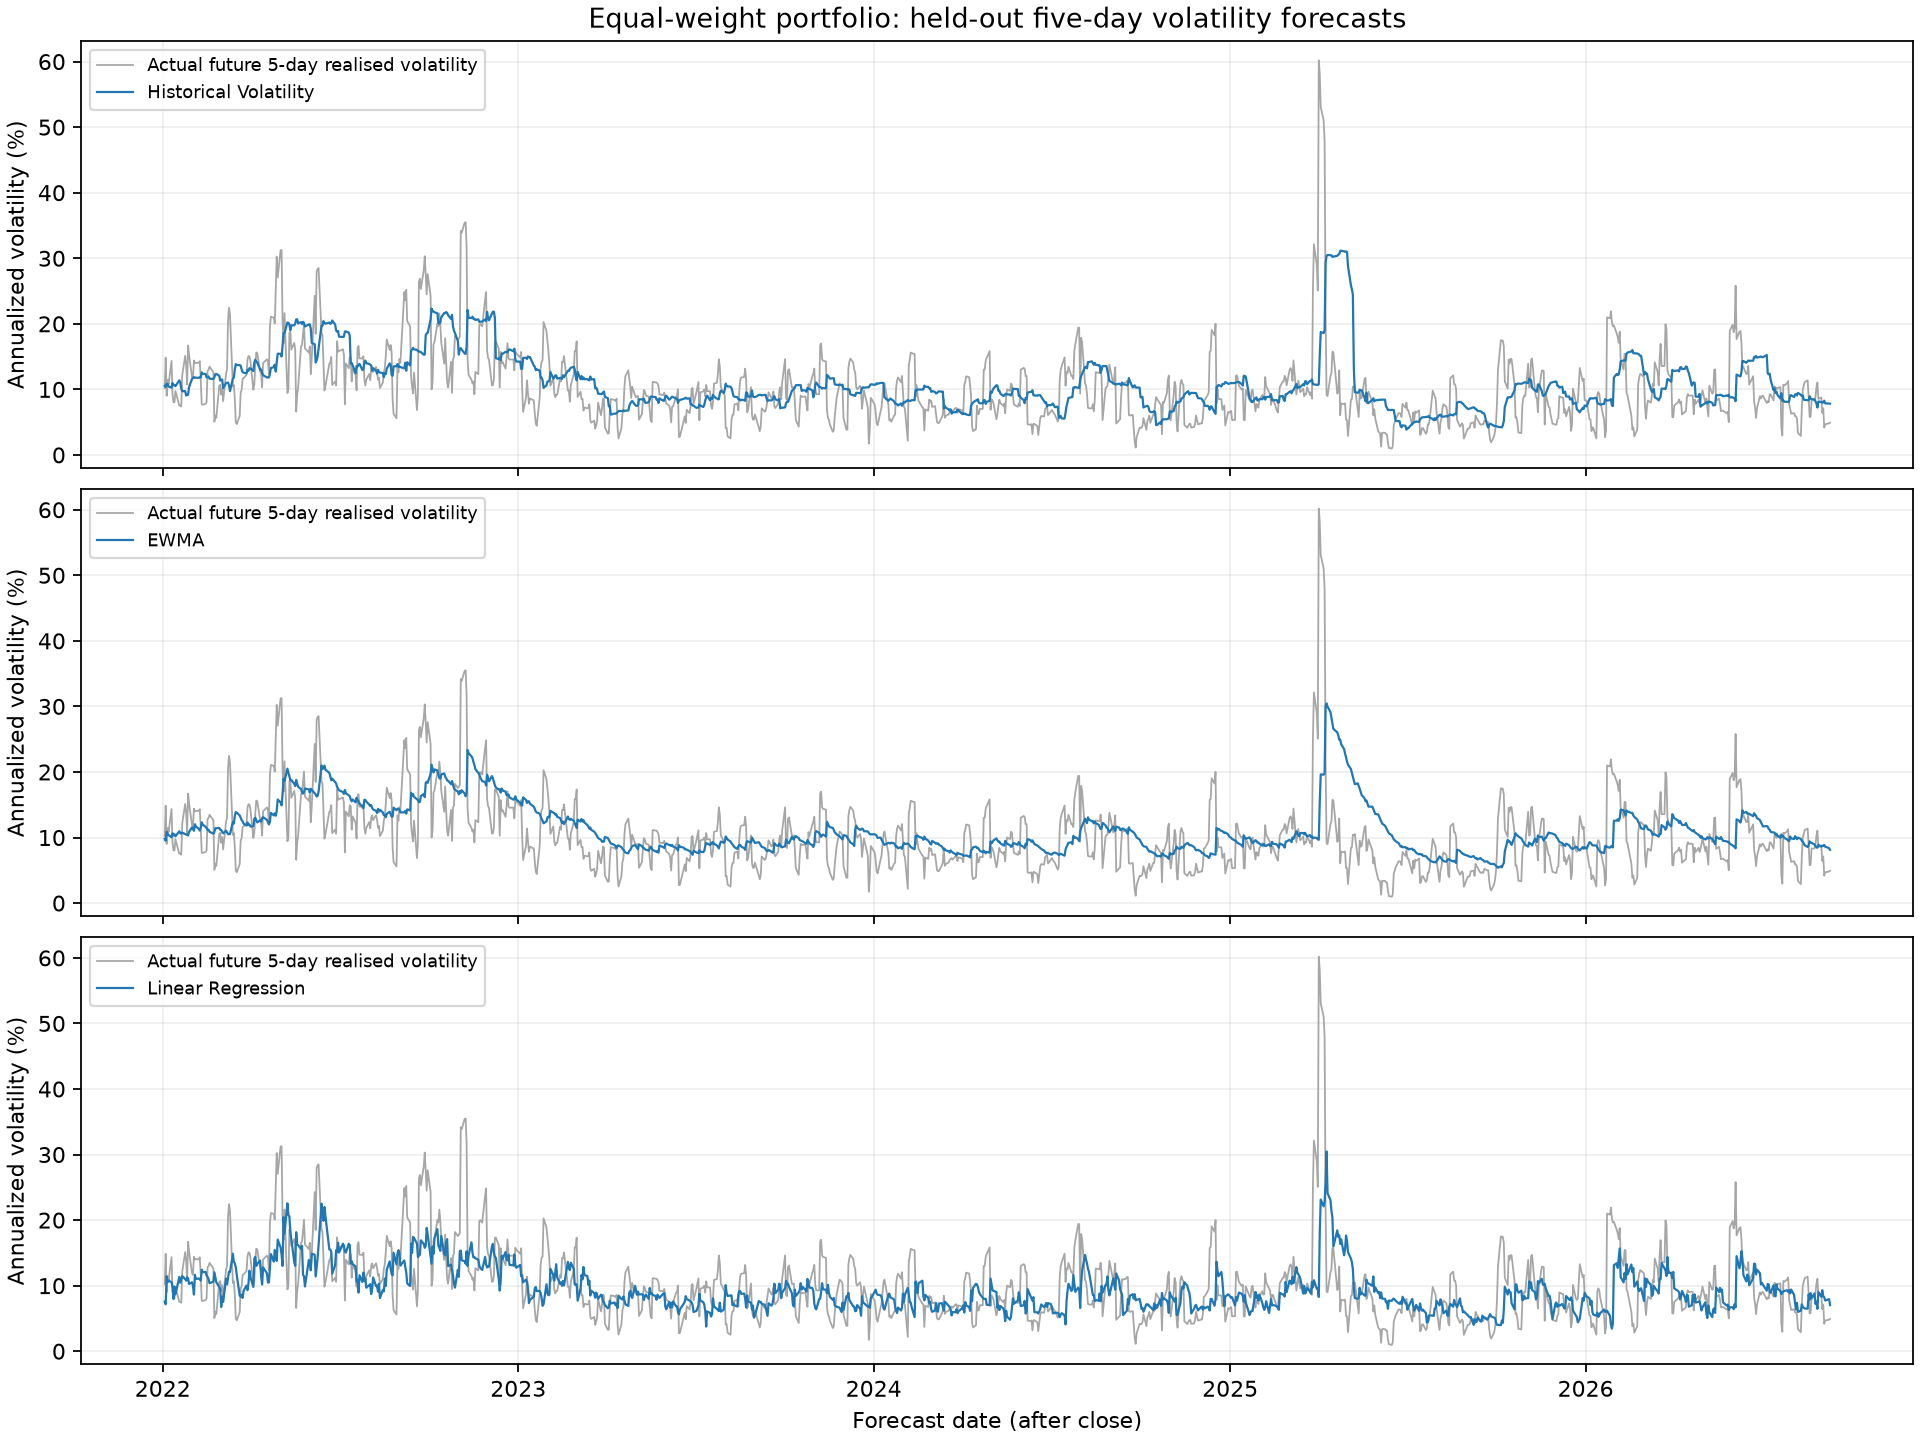

In [3]:
comparison = validation[['model', 'MAE', 'RMSE']].merge(
    test,
    on='model',
    how='left',
    suffixes=('_validation', '_test'),
)
comparison['test_status'] = np.where(
    comparison['MAE_test'].notna(),
    'evaluated',
    'not evaluated: not selected on validation',
)
comparison.to_csv(TABLE_DIR / 'model_comparison.csv', index=False)
display(comparison)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
validation_plot = comparison.sort_values('MAE_validation', ascending=True)
axes[0].barh(validation_plot['model'], validation_plot['MAE_validation'] * 100, color='#235789')
axes[0].set_xlabel('MAE (volatility percentage points)')
axes[0].set_title('Validation: all five models')

test_plot = test.sort_values('MAE', ascending=True)
position = np.arange(len(test_plot))
width = 0.36
axes[1].barh(position - width / 2, test_plot['MAE'] * 100, width, label='MAE', color='#235789')
axes[1].barh(position + width / 2, test_plot['RMSE'] * 100, width, label='RMSE', color='#c1292e')
axes[1].set_yticks(position, test_plot['model'])
axes[1].set_xlabel('Error (volatility percentage points)')
axes[1].set_title('Held-out test: baselines and selected ML model')
axes[1].legend()
figure.suptitle('Five-day realised volatility forecast errors')
figure.savefig(FIGURE_DIR / 'model_errors.png', dpi=160)
if plt.get_backend().lower() != 'agg':
    plt.show()
plt.close(figure)

display(Image(filename=str(FIGURE_DIR / 'test_volatility_forecasts.png')))

## Five-day VaR backtesting

VaR is based on the saved test volatility forecasts and a zero-mean normal assumption.
The formal Kupiec tests use 235 non-overlapping five-trading-day outcome windows per
model and confidence level. A p-value above 0.05 is not proof of correct calibration,
especially at 99% confidence where only 2.35 violations are expected.

,model,confidence,observations,violations,violation_rate,expected_violation_rate,kupiec_statistic,kupiec_p_value
0,Historical Volatility,0.95,235,10,0.042553,0.05,0.288319,0.591300
1,Historical Volatility,0.99,235,3,0.012766,0.01,0.166999,0.682792
2,EWMA,0.95,235,8,0.034043,0.05,1.412053,0.234716
3,EWMA,0.99,235,1,0.004255,0.01,0.998988,0.317556
4,Linear Regression,0.95,235,15,0.063830,0.05,0.873453,0.350001
5,Linear Regression,0.99,235,4,0.017021,0.01,0.966762,0.325489


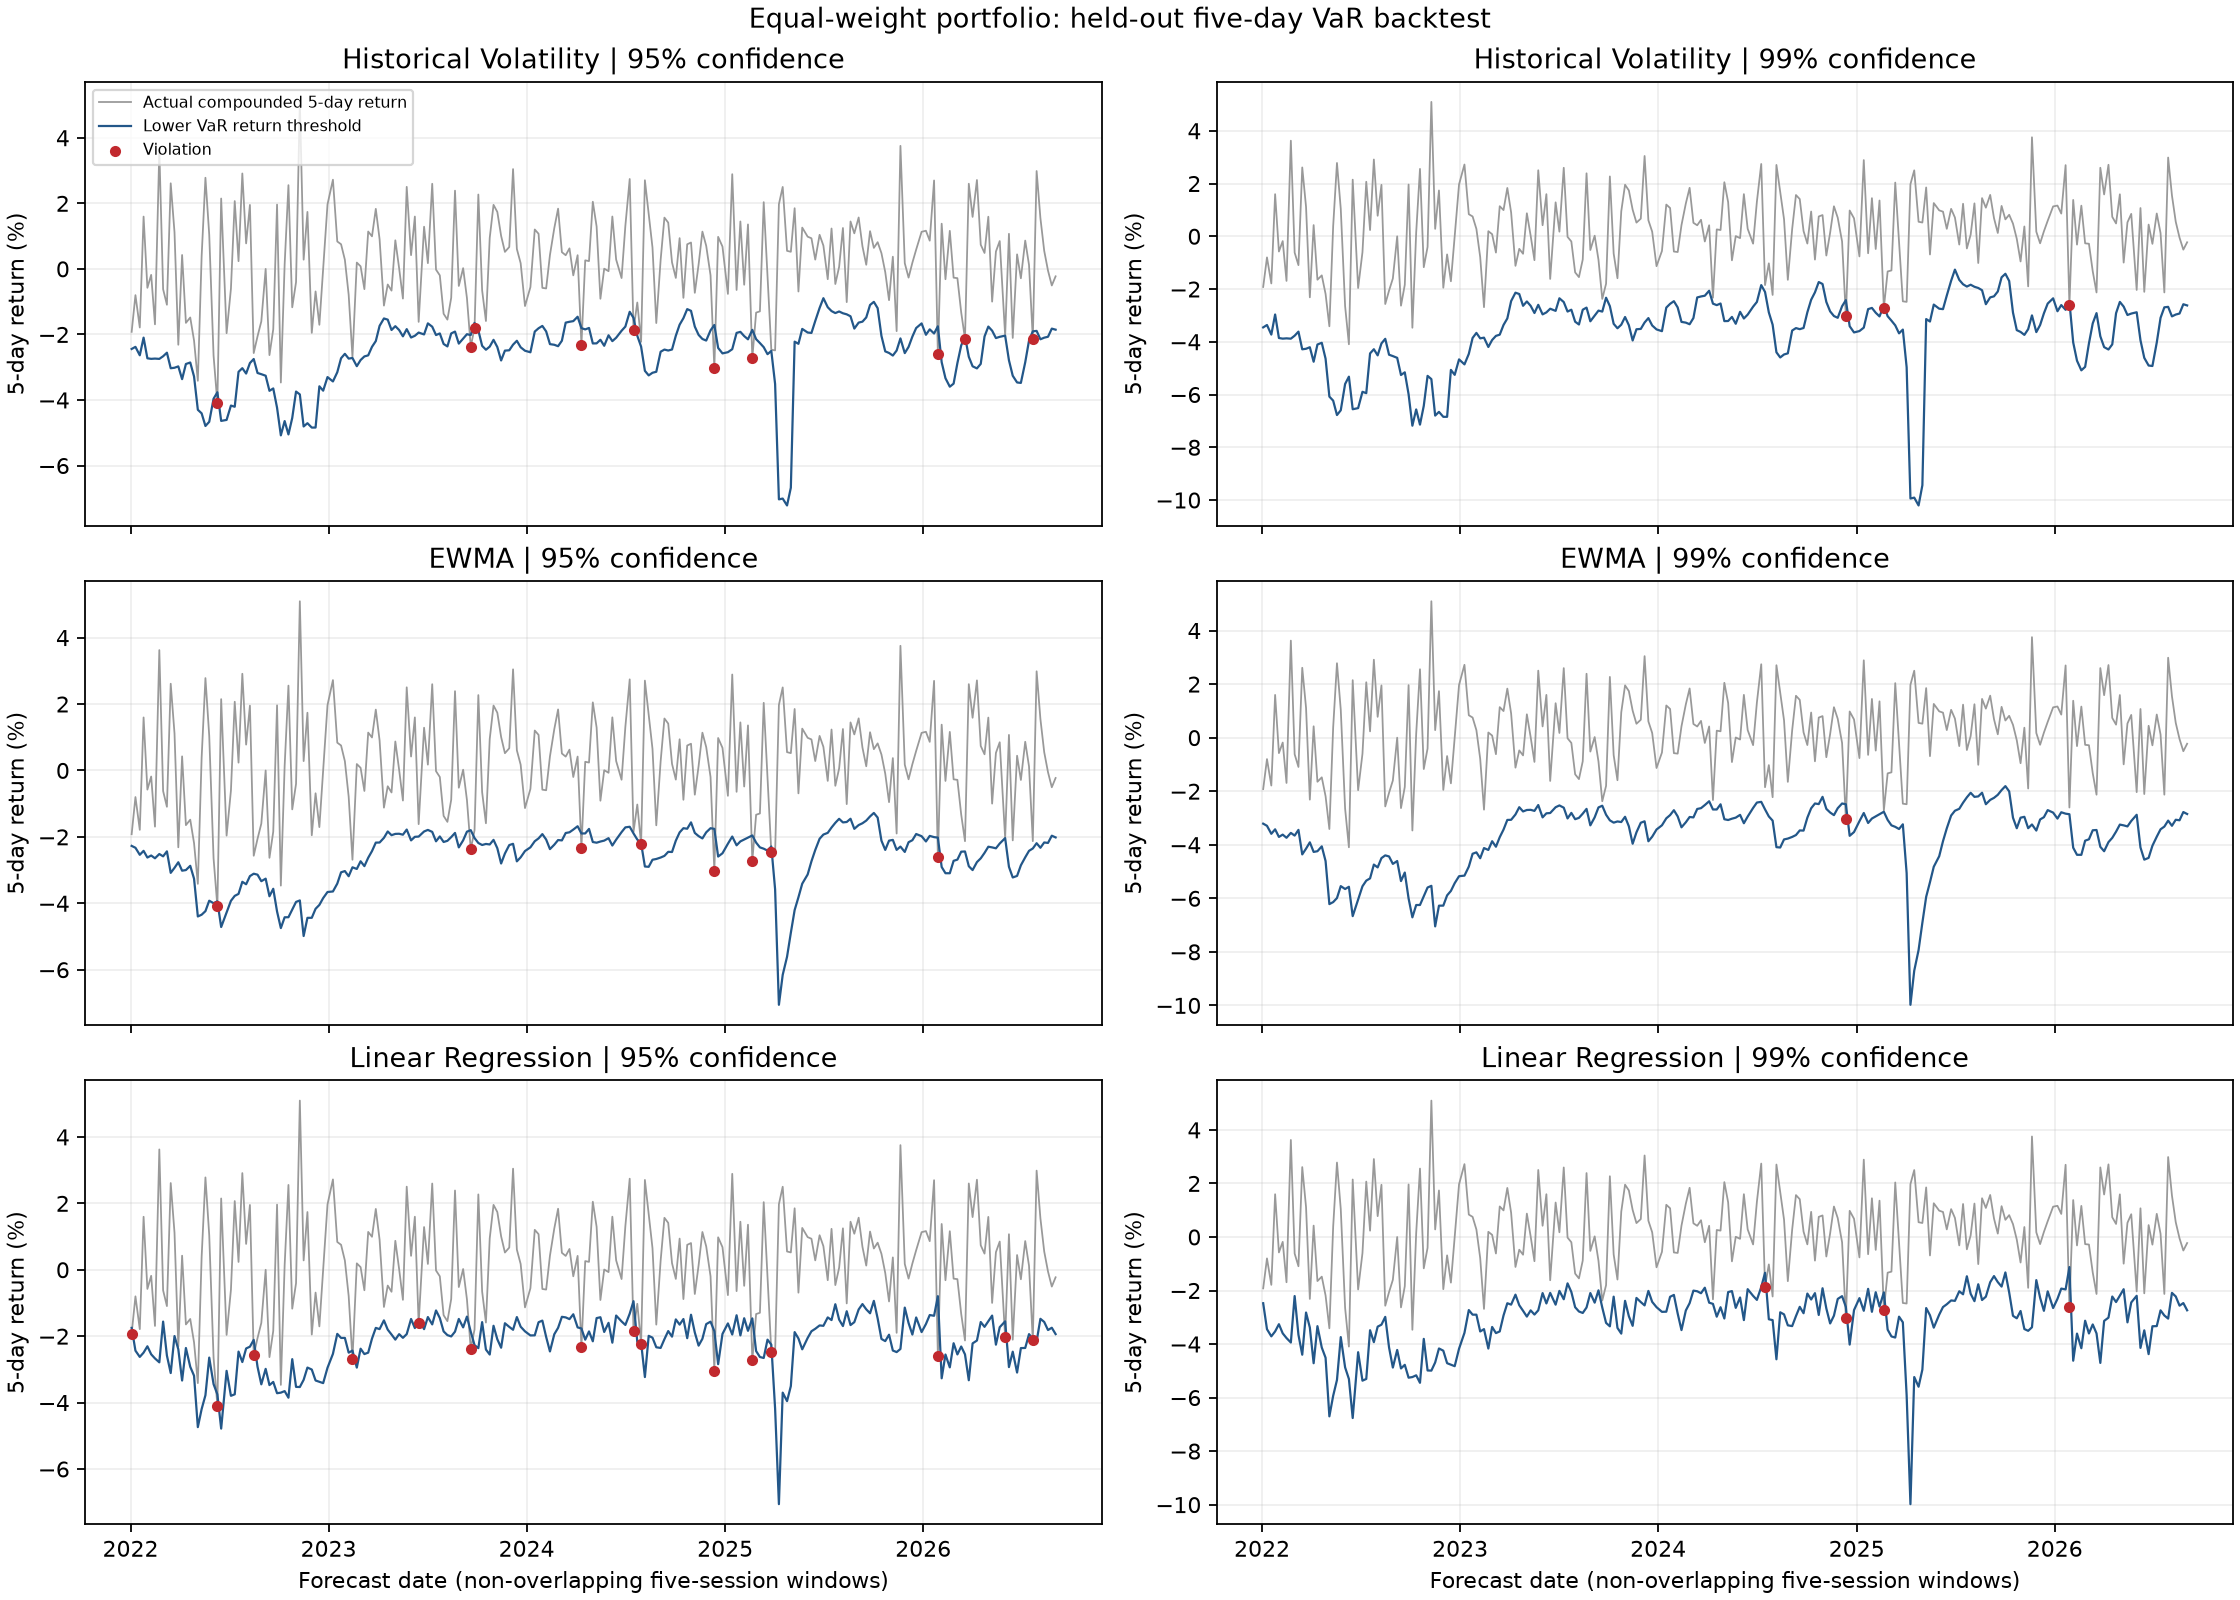

The validation-selected model was Linear Regression.

Its held-out test MAE was 0.035502 and its RMSE was 0.052967 in annualized volatility units.

Its test RMSE was 7.34% lower than EWMA, the lower-RMSE baseline. This is a descriptive comparison.

Historical Volatility at 95%: 10/235 violations (4.26%); Kupiec p=0.5913.

Historical Volatility at 99%: 3/235 violations (1.28%); Kupiec p=0.6828.

EWMA at 95%: 8/235 violations (3.40%); Kupiec p=0.2347.

EWMA at 99%: 1/235 violations (0.43%); Kupiec p=0.3176.

Linear Regression at 95%: 15/235 violations (6.38%); Kupiec p=0.3500.

Linear Regression at 99%: 4/235 violations (1.70%); Kupiec p=0.3255.

In [4]:
display(backtests)
display(Image(filename=str(FIGURE_DIR / 'var_violations.png')))

selected_model = selection['selected_ml_model']
selected_test = test.set_index('model').loc[selected_model]
baseline_test = test[test['model'].isin(['Historical Volatility', 'EWMA'])]
best_baseline = baseline_test.sort_values('RMSE').iloc[0]
relative_rmse = (selected_test['RMSE'] / best_baseline['RMSE'] - 1) * 100

finding_lines = [
    f"The validation-selected model was {selected_model}.",
    (
        f"Its held-out test MAE was {selected_test['MAE']:.6f} and its RMSE was "
        f"{selected_test['RMSE']:.6f} in annualized volatility units."
    ),
    (
        f"Its test RMSE was {abs(relative_rmse):.2f}% "
        f"{'lower' if relative_rmse < 0 else 'higher'} than {best_baseline['model']}, "
        "the lower-RMSE baseline. This is a descriptive comparison."
    ),
]
for row in backtests.itertuples(index=False):
    finding_lines.append(
        f"{row.model} at {row.confidence:.0%}: {row.violations}/{row.observations} "
        f"violations ({row.violation_rate:.2%}); Kupiec p={row.kupiec_p_value:.4f}."
    )
findings_text = '\n\n'.join(finding_lines)
(TABLE_DIR / 'findings.md').write_text(findings_text, encoding='utf-8')
display(Markdown(findings_text))

## Interpretation and limitations

Linear Regression had the lowest validation and test errors in this fixed experiment.
Its VaR violation rate was nevertheless higher than both baselines, showing that average
volatility error and tail-risk calibration are different criteria.

The target uses only five returns and is noisy. Results depend on one chronological split
and one historical test period. Normal VaR assumes zero expected return and square-root-of-
time volatility scaling, which can understate heavy-tailed or dependent losses. The 235
disjoint windows give limited power at 99% confidence, and the Kupiec test checks frequency
rather than violation independence. Daily rebalancing ignores costs and liquidity. Yahoo
adjusted prices may be revised, and seven ETFs do not represent every portfolio.

In [5]:
upstream_files = [
    'data/processed/daily_returns.csv',
    'data/processed/volatility_modeling_dataset.csv',
    'outputs/tables/validation_metrics.csv',
    'outputs/tables/test_metrics.csv',
    'outputs/tables/test_predictions.csv',
    'outputs/tables/kupiec_backtests.csv',
]
upstream_sha256 = {
    name: hashlib.sha256((PROJECT_ROOT / name).read_bytes()).hexdigest()
    for name in upstream_files
}

summary = {
    'status': 'PASS',
    'data': {
        'assets': expected_assets,
        'price_rows': part1_report['cleaned_prices']['rows'],
        'return_rows': part1_report['daily_returns']['rows'],
        'price_start': part1_report['cleaned_prices']['start_date'],
        'price_end': part1_report['cleaned_prices']['end_date'],
    },
    'modeling_dataset': {
        'rows': part2_report['final_modeling_rows'],
        'features': part2_report['feature_list'],
        'target': part2_report['target_name'],
        'start_date': part2_report['final_start_date'],
        'end_date': part2_report['final_end_date'],
    },
    'time_splits': splits.to_dict(orient='records'),
    'selected_ml_model': selected_model,
    'validation_metrics': validation.to_dict(orient='records'),
    'test_metrics': test.to_dict(orient='records'),
    'relative_test_rmse_to_best_baseline_percent': float(relative_rmse),
    'nonoverlapping_var_backtests': backtests.to_dict(orient='records'),
    'upstream_sha256': upstream_sha256,
    'figures': [
        'asset_portfolio_volatility.png',
        'model_errors.png',
        'test_volatility_forecasts.png',
        'var_violations.png',
    ],
}
(TABLE_DIR / 'results_summary.json').write_text(
    json.dumps(summary, indent=2),
    encoding='utf-8',
)
for figure_name in summary['figures']:
    assert (FIGURE_DIR / figure_name).is_file()
assert (backtests['observations'] == 235).all()
assert (backtests['kupiec_p_value'].between(0, 1)).all()
print('Part 5 completed from the saved, validated Parts 1–4 results.')

Part 5 completed from the saved, validated Parts 1–4 results.
